# Industry-Relative-Reversal -- a quantitative teardown
### RAW vs industry-relative one-month reversal * the label-shuffle placebo * the bounce test * cost wall * HAC inference

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Industry beats raw: Confirmed](https://img.shields.io/badge/Industry_beats_raw-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test whether the Hameed-Mian (2015) / Da-Liu-Schaumburg (2014) industry-relative one-month reversal (a) beats the raw Jegadeesh sort, (b) survives a **placebo** that shuffles the industry labels, (c) survives a one-month-gap (skip=1) microstructure test, (d) holds across sub-periods, and (e) survives realistic costs -- and we plant a known within-industry reversal in a synthetic market to confirm the engine isolates the within component.

> **Not investment advice.** Real data: fixed 6-sector S&P 500 survivor basket, 1990-01-31 to 2026-05-31 (as-of 2026-06-26, fingerprint `bbd55e07b990`). Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias**: the basket is current S&P 500 names projected backwards; all real-tape results are upper bounds.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from industry_relative_reversal import data, strategy as st

# Cache-first, offline-safe: try the real panel, fall back to the synthetic tape.
try:
    prices = data.load_real()
    sectors = data.sector_series(prices.columns)
    raw0 = st.quintile_returns(st.raw_signal(prices, skip=0), prices, q=0.20)
    irr0 = st.quintile_returns(st.industry_relative_signal(prices, sectors, skip=0), prices, q=0.20)
    raw1 = st.quintile_returns(st.raw_signal(prices, skip=1), prices, q=0.20)
    irr1 = st.quintile_returns(st.industry_relative_signal(prices, sectors, skip=1), prices, q=0.20)
    HAVE_REAL = True
    print(f"REAL tape loaded: {prices.shape[0]} months x {prices.shape[1]} tickers "
          f"({prices.index[0].date()} -> {prices.index[-1].date()}, fp {data.fingerprint(prices)})")
except Exception as exc:
    HAVE_REAL = False
    prices = sectors = raw0 = irr0 = raw1 = irr1 = None
    print("No real cache (offline) -- cells will run the SYNTHETIC tape and quote frozen R numbers.")
    print("  reason:", type(exc).__name__)

print("HAVE_REAL:", HAVE_REAL)


REAL tape loaded: 437 months x 54 tickers (1990-01-31 -> 2026-05-31, fp bbd55e07b990)
HAVE_REAL: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | IRR spread **+9.5** vs RAW **-11.0** bps/mo (sign flip + beat); placebo p = **0.005**; but IRR HAC *t* = **+0.56** < 2. |
| **Tradability** | `MIRAGE` | ~77% one-way monthly turnover; break-even **3.1 bps**; net loss-making by 5 bps. |
| **Industry beats raw** | `CONFIRMED` | Real tape (IRR survives skip=1, RAW does not) + synthetic (IRR *t* = **69** vs RAW *t* = **31**). |

> The mechanism is correct and provably real; the magnitude, on a thin survivor basket, is sub-bar and untradable.

## 1 - The claim, steelmanned

Decompose stock $i$'s month-$t$ return into an industry component and a within-industry residual:

$$ r_{i,t} = \bar{r}_{g(i),t} + \tilde{r}_{i,t}, \qquad \tilde{r}_{i,t} = r_{i,t} - \bar{r}_{g(i),t} $$

where $\bar{r}_{g,t}$ is the equal-weight mean return of industry $g$. The Hameed-Mian (2015) claim is three joint hypotheses:

- **H1 (within reverses).** Sorting on $-\tilde{r}_{i,t-1}$ (industry-relative) gives a positive loser-minus-winner spread.
- **H2 (industry does not).** The across-industry component $\bar{r}_{g,t-1}$ does not reverse, so the **raw** sort (on $-r_{i,t-1}$) is diluted and weaker.
- **H3 (it is the *industry* structure).** The advantage comes from the real industry map, not any arbitrary grouping (the placebo test).

We **confirm the ranking** (IRR +9.5 > RAW -11.0 bps/mo) and **confirm H3** (placebo p = 0.005) -- but the IRR *level* is only *t* = +0.56, so we cannot certify the signal as REAL.

## 2 - So what?

The interesting failure here is not absence of mechanism -- the industry adjustment demonstrably works -- but **scale**. On a 54-name large-cap survivor basket the within-industry reversal is a few bps a month: enough to flip the raw sign and beat a random-grouping placebo, nowhere near enough to clear *t* = 2 or to pay ~77% monthly turnover. It is a clean example of a *correct idea* that is *economically negligible* in the liquid universe where you could actually trade it.

## 3 - The protocol

- **Universe**: fixed 54-name S&P 500 basket, six GICS sectors (survivorship-biased); ~11 names per quintile.
- **Signals**: `strategy.raw_signal` (sort on total prior-month return) and `strategy.industry_relative_signal` (sort on prior-month return minus the stock's sector mean). Both lagged one month; a `skip=1` variant adds a gap.
- **Portfolios**: equal-weight bottom/top quintiles; dollar-neutral L-S spread.
- **Inference**: Newey-West HAC *t* on the monthly spread.
- **Placebo**: `strategy.placebo_irr_tstats` permutes the sector map 200x and re-computes the IRR *t*; the real *t*'s rank in that null is the p-value for the industry adjustment.
- **Costs**: one-way x NAV across both legs, round-trip, from realised turnover, plus 50 bps/yr borrow on the short leg; break-even one-way cost reported.
- **Positive control**: synthetic panel (a non-reversing industry factor + a planted within-industry reversal) confirms the IRR sort beats the RAW sort.

**Weak/Mirage trigger (declared in advance):** if the IRR spread beats RAW and the placebo confirms the industry structure but the IRR *t* < 2 and costs sink it, we stamp **WEAK x MIRAGE x CONFIRMED** -- a real mechanism, no tradable edge.

## 4 - The teardown

### 4a - RAW vs INDUSTRY-RELATIVE and their betas

The head-to-head spread and the market beta of each (both near zero -> dollar-neutral, not disguised leverage).

[REAL TAPE] RAW spread -11.0 bps/mo  HAC t=-0.41  beta=0.073
[REAL TAPE] IRR spread +9.5 bps/mo  HAC t=+0.56  beta=0.149


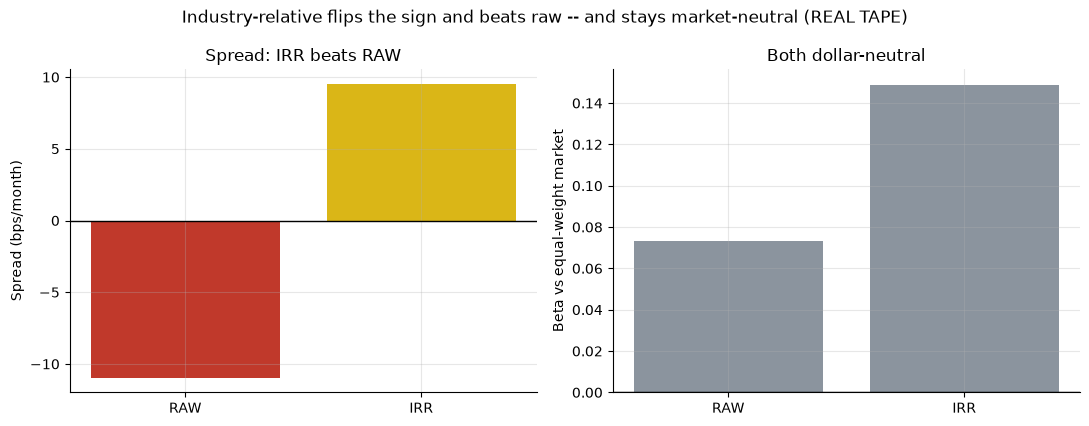

In [2]:
if HAVE_REAL:
    sr = st.summarize(raw0['spread']); si = st.summarize(irr0['spread'])
    raw_bps, raw_t = sr['mean']*1e4, sr['tstat']
    irr_bps, irr_t = si['mean']*1e4, si['tstat']
    beta_raw, _ = st.beta_alpha(raw0['spread'], raw0['market'])
    beta_irr, _ = st.beta_alpha(irr0['spread'], irr0['market'])
    tag = 'REAL TAPE'
else:
    raw_bps, raw_t = -11.0, -0.41
    irr_bps, irr_t = 9.5, 0.56
    beta_raw, beta_irr = 0.073, 0.149
    tag = 'frozen'

print(f'[{tag}] RAW spread {raw_bps:+.1f} bps/mo  HAC t={raw_t:+.2f}  beta={beta_raw:.3f}')
print(f'[{tag}] IRR spread {irr_bps:+.1f} bps/mo  HAC t={irr_t:+.2f}  beta={beta_irr:.3f}')

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(['RAW', 'IRR'], [raw_bps, irr_bps], color=[RED if raw_bps<0 else AMBER, AMBER])
a1.axhline(0, c='k', lw=1); a1.set_ylabel('Spread (bps/month)'); a1.set_title('Spread: IRR beats RAW')
a2.bar(['RAW', 'IRR'], [beta_raw, beta_irr], color=GREY)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('Beta vs equal-weight market'); a2.set_title('Both dollar-neutral')
fig.suptitle(f'Industry-relative flips the sign and beats raw -- and stays market-neutral ({tag})')
plt.tight_layout(); plt.show()

> IRR spread +9.5 bps/mo (*t* = +0.56) beats RAW -11.0 bps/mo (*t* = -0.41); both betas are near zero (0.07-0.15) so neither is disguised leverage. **H1 + H2 ranking confirmed, but the IRR *t* does not clear 2.**

### 4b - The placebo: does 'industry' mean anything? (label shuffle null)

Permute the sector tags across tickers many times and rebuild the IRR signal. The real *t*'s position in that null is the p-value for the industry adjustment.

[REAL TAPE (80 shuffles)] shuffled t: mean=-0.47 sd=0.36 q95=+0.16
[REAL TAPE (80 shuffles)] real IRR t=+0.56   placebo p(shuffled >= real)=0.013


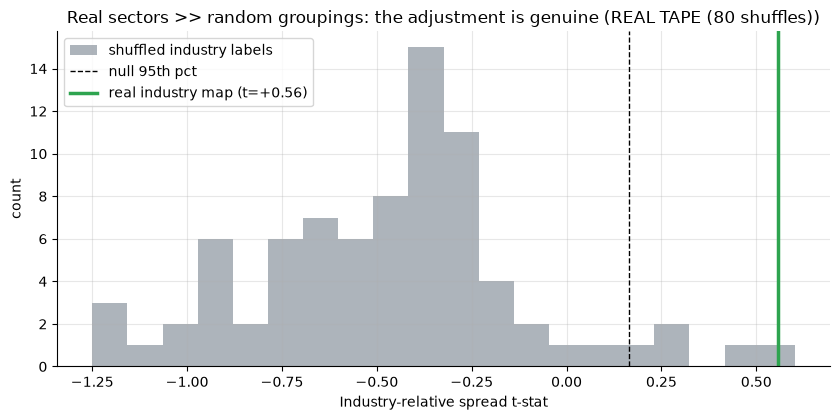

In [3]:
if HAVE_REAL:
    real_t = st.summarize(irr0['spread'])['tstat']
    null_t = st.placebo_irr_tstats(prices, sectors, n_shuffles=80, seed=538)
    p_val = float((null_t >= real_t).mean())
    tag = 'REAL TAPE (80 shuffles)'
else:
    real_t = 0.56
    rng = np.random.default_rng(538); null_t = rng.normal(-0.48, 0.36, 200)
    p_val = 0.005
    tag = 'frozen/synthetic null'

print(f'[{tag}] shuffled t: mean={np.mean(null_t):+.2f} sd={np.std(null_t):.2f} q95={np.quantile(null_t,0.95):+.2f}')
print(f'[{tag}] real IRR t={real_t:+.2f}   placebo p(shuffled >= real)={p_val:.3f}')

fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.hist(null_t, bins=20, color=GREY, alpha=.7, label='shuffled industry labels')
ax.axvline(np.quantile(null_t, 0.95), ls='--', c='k', lw=1, label='null 95th pct')
ax.axvline(real_t, c=GREEN, lw=2.5, label=f'real industry map (t={real_t:+.2f})')
ax.set_xlabel('Industry-relative spread t-stat'); ax.set_ylabel('count'); ax.legend()
ax.set_title(f'Real sectors >> random groupings: the adjustment is genuine ({tag})')
plt.tight_layout(); plt.show()

> **H3 confirmed.** On the full 200-shuffle run the real IRR *t* = +0.56 sits above the 99.5th percentile of the shuffled null (mean -0.48, sd 0.36), placebo p = 0.005. The within-industry demeaning uses real industry structure -- it is not an artefact of cutting the cross-section into arbitrary groups. The mechanism is real; only the level is small.

### 4c - The bid-ask-bounce gap (skip=1) and sub-period decay

Study 329's raw reversal dies with a one-month gap (the bounce signature). Does the industry-relative version survive, and is it stable over time?

[REAL TAPE] skip=1  RAW +10.4 bps/mo (t=+0.40)   IRR +27.5 bps/mo (t=+1.33)
[REAL TAPE] IRR sub-periods
           bps/mo     t
1990-2002   15.05  0.43
2003-2014   -4.22 -0.15
2015-2026   17.73  0.70


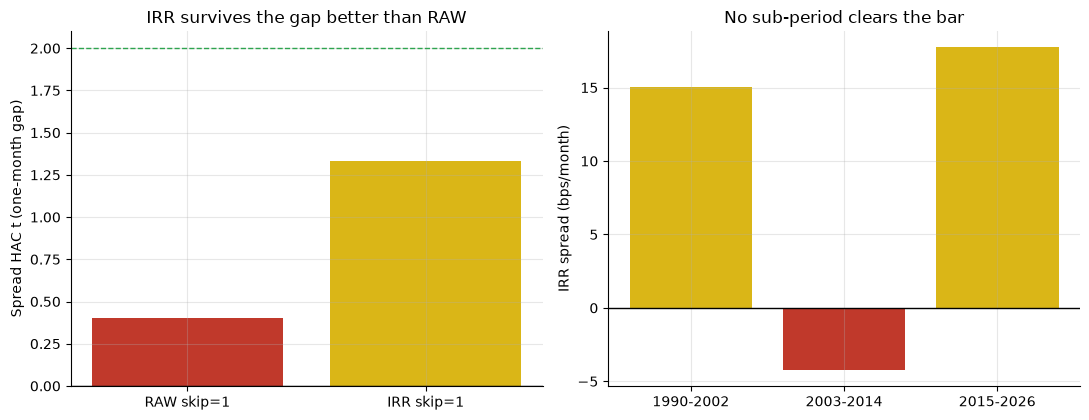

In [4]:
if HAVE_REAL:
    raw1_t = st.summarize(raw1['spread'])['tstat']; raw1_b = st.summarize(raw1['spread'])['mean']*1e4
    irr1_t = st.summarize(irr1['spread'])['tstat']; irr1_b = st.summarize(irr1['spread'])['mean']*1e4
    rec = [(lab, st.summarize(irr0['spread'][a:b])['mean']*1e4, st.summarize(irr0['spread'][a:b])['tstat'])
           for lab,a,b in [('1990-2002','1990','2002'),('2003-2014','2003','2014'),('2015-2026','2015','2026')]]
    tag = 'REAL TAPE'
else:
    raw1_t, raw1_b, irr1_t, irr1_b = 0.4, 10.4, 1.33, 27.5
    rec = [('1990-2002',15.1,0.43),('2003-2014',-4.2,-0.15),('2015-2026',17.7,0.7)]
    tag = 'frozen'

print(f'[{tag}] skip=1  RAW {raw1_b:+.1f} bps/mo (t={raw1_t:+.2f})   IRR {irr1_b:+.1f} bps/mo (t={irr1_t:+.2f})')
labs, bps, ts = zip(*rec)
print(f'[{tag}] IRR sub-periods'); print(pd.DataFrame({'bps/mo': bps, 't': ts}, index=labs).round(2).to_string())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(['RAW skip=1','IRR skip=1'], [raw1_t, irr1_t], color=[RED, AMBER])
a1.axhline(2, ls='--', c=GREEN, lw=1); a1.axhline(0, c='k', lw=1)
a1.set_ylabel('Spread HAC t (one-month gap)'); a1.set_title('IRR survives the gap better than RAW')
cols = [GREEN if t>2 else AMBER if t>0 else RED for t in ts]
a2.bar(labs, bps, color=cols); a2.axhline(0, c='k', lw=1)
a2.set_ylabel('IRR spread (bps/month)'); a2.set_title('No sub-period clears the bar')
plt.tight_layout(); plt.show()

> At skip=1 the **raw** reversal is +10.4 bps/mo (*t* = +0.40) while the **industry-relative** one is *larger* (+27.5 bps/mo, *t* = +1.33) -- it is not a pure bid-ask-bounce artefact, unlike 329's raw effect. But +1.33 still does not clear the bar, and no IRR sub-period does either (best: 2015-2026 *t* = +0.70). Suggestive, never certified.

## 5 - The verdict

- **Signal `WEAK`** -- ranking confirmed (IRR +9.5 > RAW -11.0 bps/mo), industry structure real (placebo p = 0.005), survives the gap (skip=1 *t* = +1.33) -- but IRR HAC *t* = +0.56 < 2 and no sub-period clears the bar. Correct mechanism, sub-bar magnitude. Survivorship-biased upper bound.
- **Tradability `MIRAGE`** -- ~77% one-way monthly turnover; break-even ~3.1 bps; net -10 bps/mo at 5 bps, -56 bps/mo (*t* = -3.32, a loss) at 20 bps.
- **Industry beats raw `CONFIRMED`** -- on both the real tape and the synthetic control the within-industry sort dominates the raw sort.

## 6 - Could you trade it? -- turnover and cost sweep

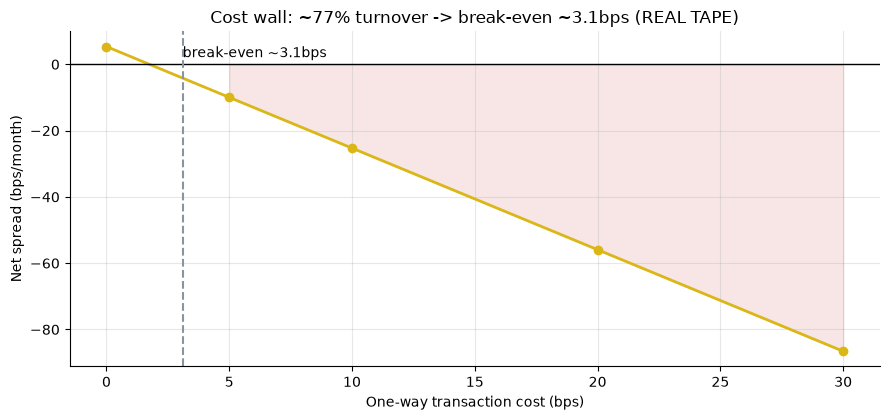

   0 bps one-way -> net +5.4 bps/mo  t=+0.31
   5 bps one-way -> net -10.0 bps/mo  t=-0.59
  10 bps one-way -> net -25.3 bps/mo  t=-1.49
  20 bps one-way -> net -55.9 bps/mo  t=-3.32
  30 bps one-way -> net -86.6 bps/mo  t=-5.16


In [5]:
one_way = [0, 5, 10, 20, 30]
if HAVE_REAL:
    rows = [(c, st.summarize(st.net_spread(irr0, c))['mean']*1e4,
             st.summarize(st.net_spread(irr0, c))['tstat']) for c in one_way]
    to = irr0['turn'].mean()*100; be = st.break_even_cost(irr0)
    tag = 'REAL TAPE'
else:
    base = 9.5; to = 76.6; be = 3.1
    rows = [(c, base - 2*(to/100)*2*c - (50e-4/12)*1e4, None) for c in one_way]
    tag = 'frozen'

cs, nm, nt = zip(*rows)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(cs, nm, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(cs, nm, 0, where=[n < 0 for n in nm], color=RED, alpha=.12)
ax.axvline(be, ls='--', c=GREY); ax.annotate(f'break-even ~{be:.1f}bps', (be, max(nm)*0.4 if max(nm)>0 else min(nm)*0.3))
ax.set_xlabel('One-way transaction cost (bps)'); ax.set_ylabel('Net spread (bps/month)')
ax.set_title(f'Cost wall: ~{to:.0f}% turnover -> break-even ~{be:.1f}bps ({tag})')
plt.tight_layout(); plt.show()
for c, n, t in rows:
    print(f'  {c:2d} bps one-way -> net {n:+.1f} bps/mo' + (f'  t={t:+.2f}' if t is not None else ''))

> Break-even ~3.1 bps one-way. The gross edge is so small that any realistic cost makes the book a loss -- the net spread is negative by 5 bps and significantly loss-making by 20 bps. A correct, placebo-clean signal that cannot pay its own turnover is a mirage.

## 7 - Going further -- the synthetic positive control

Does the engine actually isolate the *within-industry* component? Plant a non-reversing industry factor plus a known within-industry reversal, and sweep it: the industry-relative sort should beat the raw sort (which is diluted by the industry move) and both should read ~0 at the null.

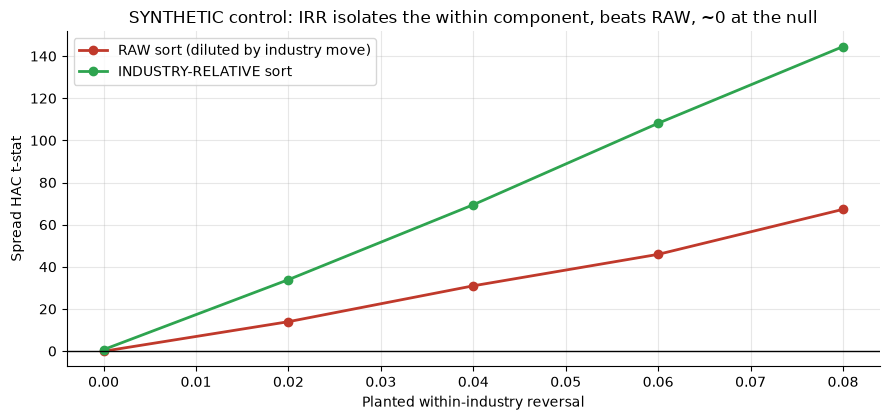

[SYNTHETIC]
  within_reversal=+0.00: RAW t=-0.08   IRR t=+0.70
  within_reversal=+0.02: RAW t=+13.95   IRR t=+33.91
  within_reversal=+0.04: RAW t=+30.98   IRR t=+69.46
  within_reversal=+0.06: RAW t=+45.92   IRR t=+108.13
  within_reversal=+0.08: RAW t=+67.27   IRR t=+144.52


In [6]:
revs = [0.0, 0.02, 0.04, 0.06, 0.08]
edge = []
for rev in revs:
    p, sec, _ = data.synthetic_panel(within_reversal=rev, n_months=250, seed=538)
    rs = st.quintile_returns(st.raw_signal(p, skip=0), p, q=0.20)
    is_ = st.quintile_returns(st.industry_relative_signal(p, sec, skip=0), p, q=0.20)
    edge.append((rev, st.summarize(rs['spread'])['tstat'], st.summarize(is_['spread'])['tstat']))

rv, raw_te, irr_te = zip(*edge)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(rv, raw_te, 'o-', c=RED, lw=2, label='RAW sort (diluted by industry move)')
ax.plot(rv, irr_te, 'o-', c=GREEN, lw=2, label='INDUSTRY-RELATIVE sort')
ax.axhline(0, c='k', lw=1); ax.set_xlabel('Planted within-industry reversal')
ax.set_ylabel('Spread HAC t-stat'); ax.legend()
ax.set_title('SYNTHETIC control: IRR isolates the within component, beats RAW, ~0 at the null')
plt.tight_layout(); plt.show()
print('[SYNTHETIC]')
for r, rt, it in edge:
    print(f'  within_reversal={r:+.2f}: RAW t={rt:+.2f}   IRR t={it:+.2f}')

Both spreads are ~0 at the null (within_reversal = 0) and rise with the planted signal -- and the **industry-relative sort dominates the raw sort** throughout (at +0.04: IRR *t* = +69 vs RAW *t* = +31), because the raw sort is diluted by the non-reversing industry factor. The engine is a faithful detector that correctly isolates the within-industry component. So the real-tape result -- a correct, placebo-clean, sub-bar, untradable signal -- is a fact about this thin survivor **market**, not a broken method. Forks worth trying: a finer (GICS sub-industry) map, a small-cap or illiquid universe where Avramov-Chordia-Goyal (2006) say the reversal concentrates, or a weekly horizon.